In [1]:
import pandas as pd
import numpy as np
import functions_for_analyze as ffa
import single_output_parser as sop
import os
from types import SimpleNamespace
import matplotlib.pyplot as pp
from importlib import reload
from matplotlib.colors import TABLEAU_COLORS 
import _daily_reporters as dr
import json
from __visuals__ import matplot
from __visuals__ import _printing_and_display_functions as pad
import _interaction_functions as IF
import _Plot_from_Tables as PFT
import Make_Interaction_Tables as MIT
import pickle

%matplotlib widget

In [2]:
style_sheet = "./__visuals__/f12xg_plot_style.mplstyle"
pp.style.use(style_sheet)

In [3]:
def gen_fig_title(sysd, plot_type="Interaction energies"):
    return f"{sysd['mono1_name']}-{sysd['mono2_name']} {plot_type}"

def gen_fig_fname(sysd, ext='svg', plot_type="Interaction_energies", folder=None):
    fname= f"{sysd['mono1_name']}_{sysd['mono2_name']}_{plot_type}.{ext}"
    if folder is None:
        folder = '__Analysis_Outputs__/'
    fname = os.path.join(folder, fname)
    return fname

In [4]:
def infer_cores(sysd):
    """Infer the 'cores' list by reading the dimer's bse_data_*.csv metacsv (per base.json)."""
    dimer_bse_datafile = f"{sysd['dimer_dir']}/{sysd['method_dir']}/{sysd['basename']}"
    _, dimer_df = ffa.MakeTables.read_metacsv(
        dimer_bse_datafile, kwargs2=sysd['dimer_kwargs2']
    )
    return sorted(set(dimer_df.index.get_level_values(0)))

def build_sysd(mono1_dir, mono2_dir, dimer_dir, method_dir, bases_family,
               base_json='queryFiles/base.json', mono1_name=None, mono2_name=None):
    """Build a sysd dict via Make_Interaction_Tables.build_sysd, with 'cores' inferred from disk."""
    base = MIT.load_base_config(base_json)
    args = SimpleNamespace(
        mono1_dir=mono1_dir, mono2_dir=mono2_dir,
        dimer_dir=dimer_dir, method_dir=method_dir,
        bases_family=bases_family, base_json=base_json,
        mono1_name=mono1_name, mono2_name=mono2_name,
    )
    sysd, outer_index = MIT.build_sysd(args, base)
    sysd['outer_index'] = outer_index
    sysd['cores'] = infer_cores(sysd)
    return sysd, outer_index

# DFMP2 for Ne-Ar interactions

In [ ]:
method = 'dfmp2'
mono1_dir = 'ne'
mono2_dir = 'ar'
dimer_dir = 'ne_ar'

In [ ]:
reload(PFT)
reload(MIT)
sysd_core_valence, _ = build_sysd(mono1_dir, mono2_dir, dimer_dir, method, bases_family='core-valence')
dfs_core_valence = PFT.get_dfs(sysd_core_valence)

# ==== Now pVXZ basis
sysd_pV, _ = build_sysd(mono1_dir, mono2_dir, dimer_dir, method, bases_family='valence')
dfs_pV = PFT.get_dfs(sysd_pV)
#plot_core

## Interaction energies

### Filter and get plot data

In [ ]:
filter_specs=dict(
    cross_filters={
        "func_kwargs": [
            dict(totkey=("HF + ", "CorrE(CBS)")), 
            dict(totkey=("Reference Energy", "5"))
        ],
        "core": ["all electron", "frozen"],
    },
)

In [ ]:
reload(IF)
filter_specs['common_filter'] = {"basis": "aug-cc-pVXZ"}
filters = ffa.expand_filter_grid(**filter_specs)
plot_data = IF.collect_interaction_data(dfs_pV, filters)
filter_specs['common_filter'] = {"basis": "aug-cc-pwCVXZ"}
filters = ffa.expand_filter_grid(**filter_specs)
plot_data += IF.collect_interaction_data(dfs_core_valence, filters)

"""
for x,y, labels in plot_data:
    print(f"{labels}")
    print(x[0], x[-1])
    print(y[0], y[-1])
#"""


In [ ]:
styles0 = {# common styles for all
    "basis" : {
        "aug-cc-pVXZ" : dict(color='tab:blue', label='pVXZ', linewidth=2),
        "aug-cc-pwCVXZ" : dict(color='tab:orange', label='pwCVXZ'),
    },
    "core" : {
        "frozen" : dict(marker='x', label='frozen'),
        "all electron"  : dict(marker='s', fillstyle='none', label='all e')
    }
}

styles = dict(styles0)
styles.update(
    {
        "totkey": {
            ("HF + ", "CorrE(CBS)") : dict(linestyle='-', label='HF5+CBS'),
            ("Reference Energy", "5") : dict(linestyle=':', label='HF5'),
        }
    }
)
                                         

### Plot with Legend

In [ ]:
reload(PFT)
fig, ax, leg_ax = PFT.plot_with_external_style_legend(plot_data, styles, convert=10**(3))
ax.set_ylim(-0.5, 0.2)
ax.set_ylabel(rf"Energy (mH)")
ax.set_xlim(3,4.25)
ax.set_xlabel(r"Distance, $r$ $(\AA)$")
fig.suptitle(gen_fig_title(sysd_pV))

# F12

In [5]:
method = 'f12'
mono1_dir = 'ne'
mono2_dir = 'ar'
dimer_dir = 'ne_ar'

In [6]:
gamma = 1.0

reload(PFT)
reload(MIT)
sysd_core_valence, _ = build_sysd(mono1_dir, mono2_dir, dimer_dir, method, bases_family='core-valence')
dfs_core_valence = PFT.get_dfs(sysd_core_valence, gamma=gamma)

# ==== Now pVXZ basis
sysd_pV, _ = build_sysd(mono1_dir, mono2_dir, dimer_dir, method, bases_family='valence')
dfs_pV = PFT.get_dfs(sysd_pV, gamma=gamma)
#plot_core

### Filter and get plot data

In [7]:
filter_specs=dict(
    cross_filters={
        "func_kwargs": [
            dict(totkey=("HF + ", "CorrE(CBS)")), 
            dict(totkey=("Reference Energy", "5"))
        ],
        "core": ["all electron", "frozen"],
    },
)

In [8]:
reload(IF)
filter_specs['common_filter'] = {"basis": "aug-cc-pVXZ", "gammas" : 1.0}
filters = ffa.expand_filter_grid(**filter_specs)
plot_data = IF.collect_interaction_data(dfs_pV, filters)
filter_specs['common_filter'] = {"basis": "aug-cc-pwCVXZ", "gammas" : 1.0}
filters = ffa.expand_filter_grid(**filter_specs)
plot_data += IF.collect_interaction_data(dfs_core_valence, filters)

"""
for x,y, labels in plot_data:
    print(f"{labels}")
    print(x[0], x[-1])
    print(y[0], y[-1])
#"""


'\nfor x,y, labels in plot_data:\n    print(f"{labels}")\n    print(x[0], x[-1])\n    print(y[0], y[-1])\n#'

In [9]:
styles0 = {# common styles for all
    "basis" : {
        "aug-cc-pVXZ" : dict(color='tab:blue', label='pVXZ', linewidth=2),
        "aug-cc-pwCVXZ" : dict(color='tab:orange', label='pwCVXZ'),
    },
    "core" : {
        "frozen" : dict(marker='x', label='frozen'),
        "all electron"  : dict(marker='s', fillstyle='none', label='all e')
    }
}

styles = dict(styles0)
styles.update(
    {
        "totkey": {
            ("HF + ", "CorrE(CBS)") : dict(linestyle='-', label='HF5+CBS'),
            ("Reference Energy", "5") : dict(linestyle=':', label='HF5'),
        }
    }
)
                                         

### Plot with Legend

Text(0.5, 0.98, 'Ne-Ar Interaction energies')

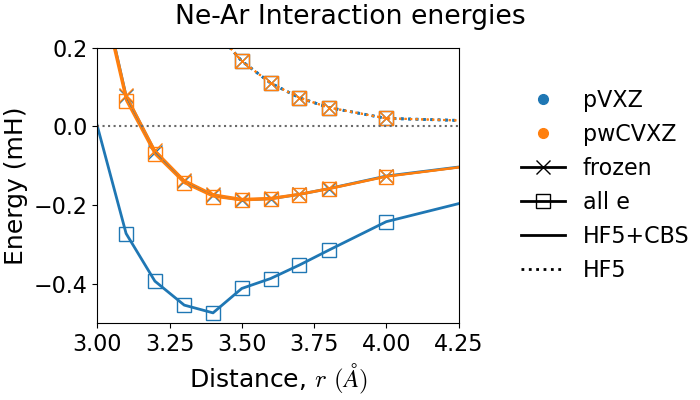

In [10]:
reload(PFT)
fig, ax, leg_ax = PFT.plot_with_external_style_legend(plot_data, styles, convert=10**(3))
ax.set_ylim(-0.5, 0.2)
ax.set_ylabel(rf"Energy (mH)")
ax.set_xlim(3,4.25)
ax.set_xlabel(r"Distance, $r$ $(\AA)$")
fig.suptitle(gen_fig_title(sysd_pV))